In [193]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd, matplotlib.gridspec as gridspec


### Max's memory plots redone

In [194]:
afc_data_raw = {
    'x': [1,10,50,100,250,500,1000,5000],
    'Ours (memory)': [1,0.75,1,1,0.94,0.88,0.88,0.69],
    'Qwen3-VL-8B (in context)': [1,1,0.75,0.81,0.75,0.69,0.62], 
    'GPT-4.1-mini (in context)': [0.42,0.62,0.75,0.75,0.94,0.88]
}
continuous_recognition_data_raw = {
    'x': [1,10,50,100,250,500,1000,5000],
    'Ours (memory)': [1,0.81,0.69,0.88,0.81,0.81,0.69,0.69],
    'Qwen3-VL-8B (in context)': [1,1,0.81,0.69,0.62,0.69,0.5], 
    'GPT-4.1-mini (in context)': [1,1,1,1,0.94,0.69]
}

afc_data = pd.DataFrame(columns=['model-id','length','accuracy'])
for model_id in ['Ours (memory)', 'Qwen3-VL-8B (in context)', 'GPT-4.1-mini (in context)']:
    for length, acc in zip(afc_data_raw['x'], afc_data_raw[model_id]):
        afc_data = pd.concat([afc_data, pd.DataFrame({'model-id': [model_id], 'length': [length], 'accuracy': [acc]})], ignore_index=True)

continuous_recognition_data = pd.DataFrame(columns=['model-id','length','accuracy'])
for model_id in ['Ours (memory)', 'Qwen3-VL-8B (in context)', 'GPT-4.1-mini (in context)']:
    for length, acc in zip(continuous_recognition_data_raw['x'], continuous_recognition_data_raw[model_id]):
        continuous_recognition_data = pd.concat([continuous_recognition_data, pd.DataFrame({'model-id': [model_id], 'length': [length], 'accuracy': [acc]})], ignore_index=True)


afc_data = pd.concat([afc_data, pd.DataFrame({'model-id': ['Human (Brady et al. 2008)'], 'length': [2500], 'accuracy': [0.93]})], ignore_index=True)  
brady_continuous = {
        'length': [1,16,32,64,128,256,512,1024], 
        'accuracy': [1.0,0.98,0.96,0.96,0.92,0.88,0.83,0.79]
}
for length, acc in zip(brady_continuous['length'], brady_continuous['accuracy']):
        continuous_recognition_data = pd.concat([continuous_recognition_data, pd.DataFrame({'model-id': ['Human (Brady et al. 2008)'], 'length': [length], 'accuracy': [acc]})], ignore_index=True)


In [195]:
# fig, ax = plt.subplots(2,1, figsize=(10,10), dpi=200)
# fig.suptitle('Recognition Memory', fontsize=20)
# plt.setp(ax, xticks=[1,10,50,100,250,500,1000,2000], yticks=[0.4,0.6,0.8,1.0], ylim=(0.395,1.05), xlim=(-100,2100)) 

# ax[0].set_title('Continuous Recognition (old/new)', fontsize=20)
# ax[0].set_ylabel('Accuracy', fontsize=14)
# ax[0].set_xlabel('Sequence Length (Number of Memorized Images)', fontsize=14)
# ax[0].hlines(0.5, xmin=1, xmax=2000, colors='gray', linestyles='dashed')
# sns.lineplot(data=continuous_recognition_data, x='length', y='accuracy', hue='model-id', marker='o', ax=ax[0], linewidth=3, markersize=10)
# ax[0].legend(title="") 

# ax[1].set_title('2-Alternative-Forced-Choice Recognition', fontsize=20)
# ax[1].set_ylabel('Accuracy', fontsize=14)
# ax[1].set_xlabel('Sequence Length (Number of Memorized Images)', fontsize=14)
# ax[1].hlines(0.5, xmin=-1000, xmax=2000, colors='gray', linestyles='dashed')
# sns.lineplot(data=afc_data, x='length', y='accuracy', hue='model-id', marker='o', ax=ax[1], linewidth=3, markersize=10)
# ax[1].legend(title="") 

# plt.tight_layout()
# plt.show()

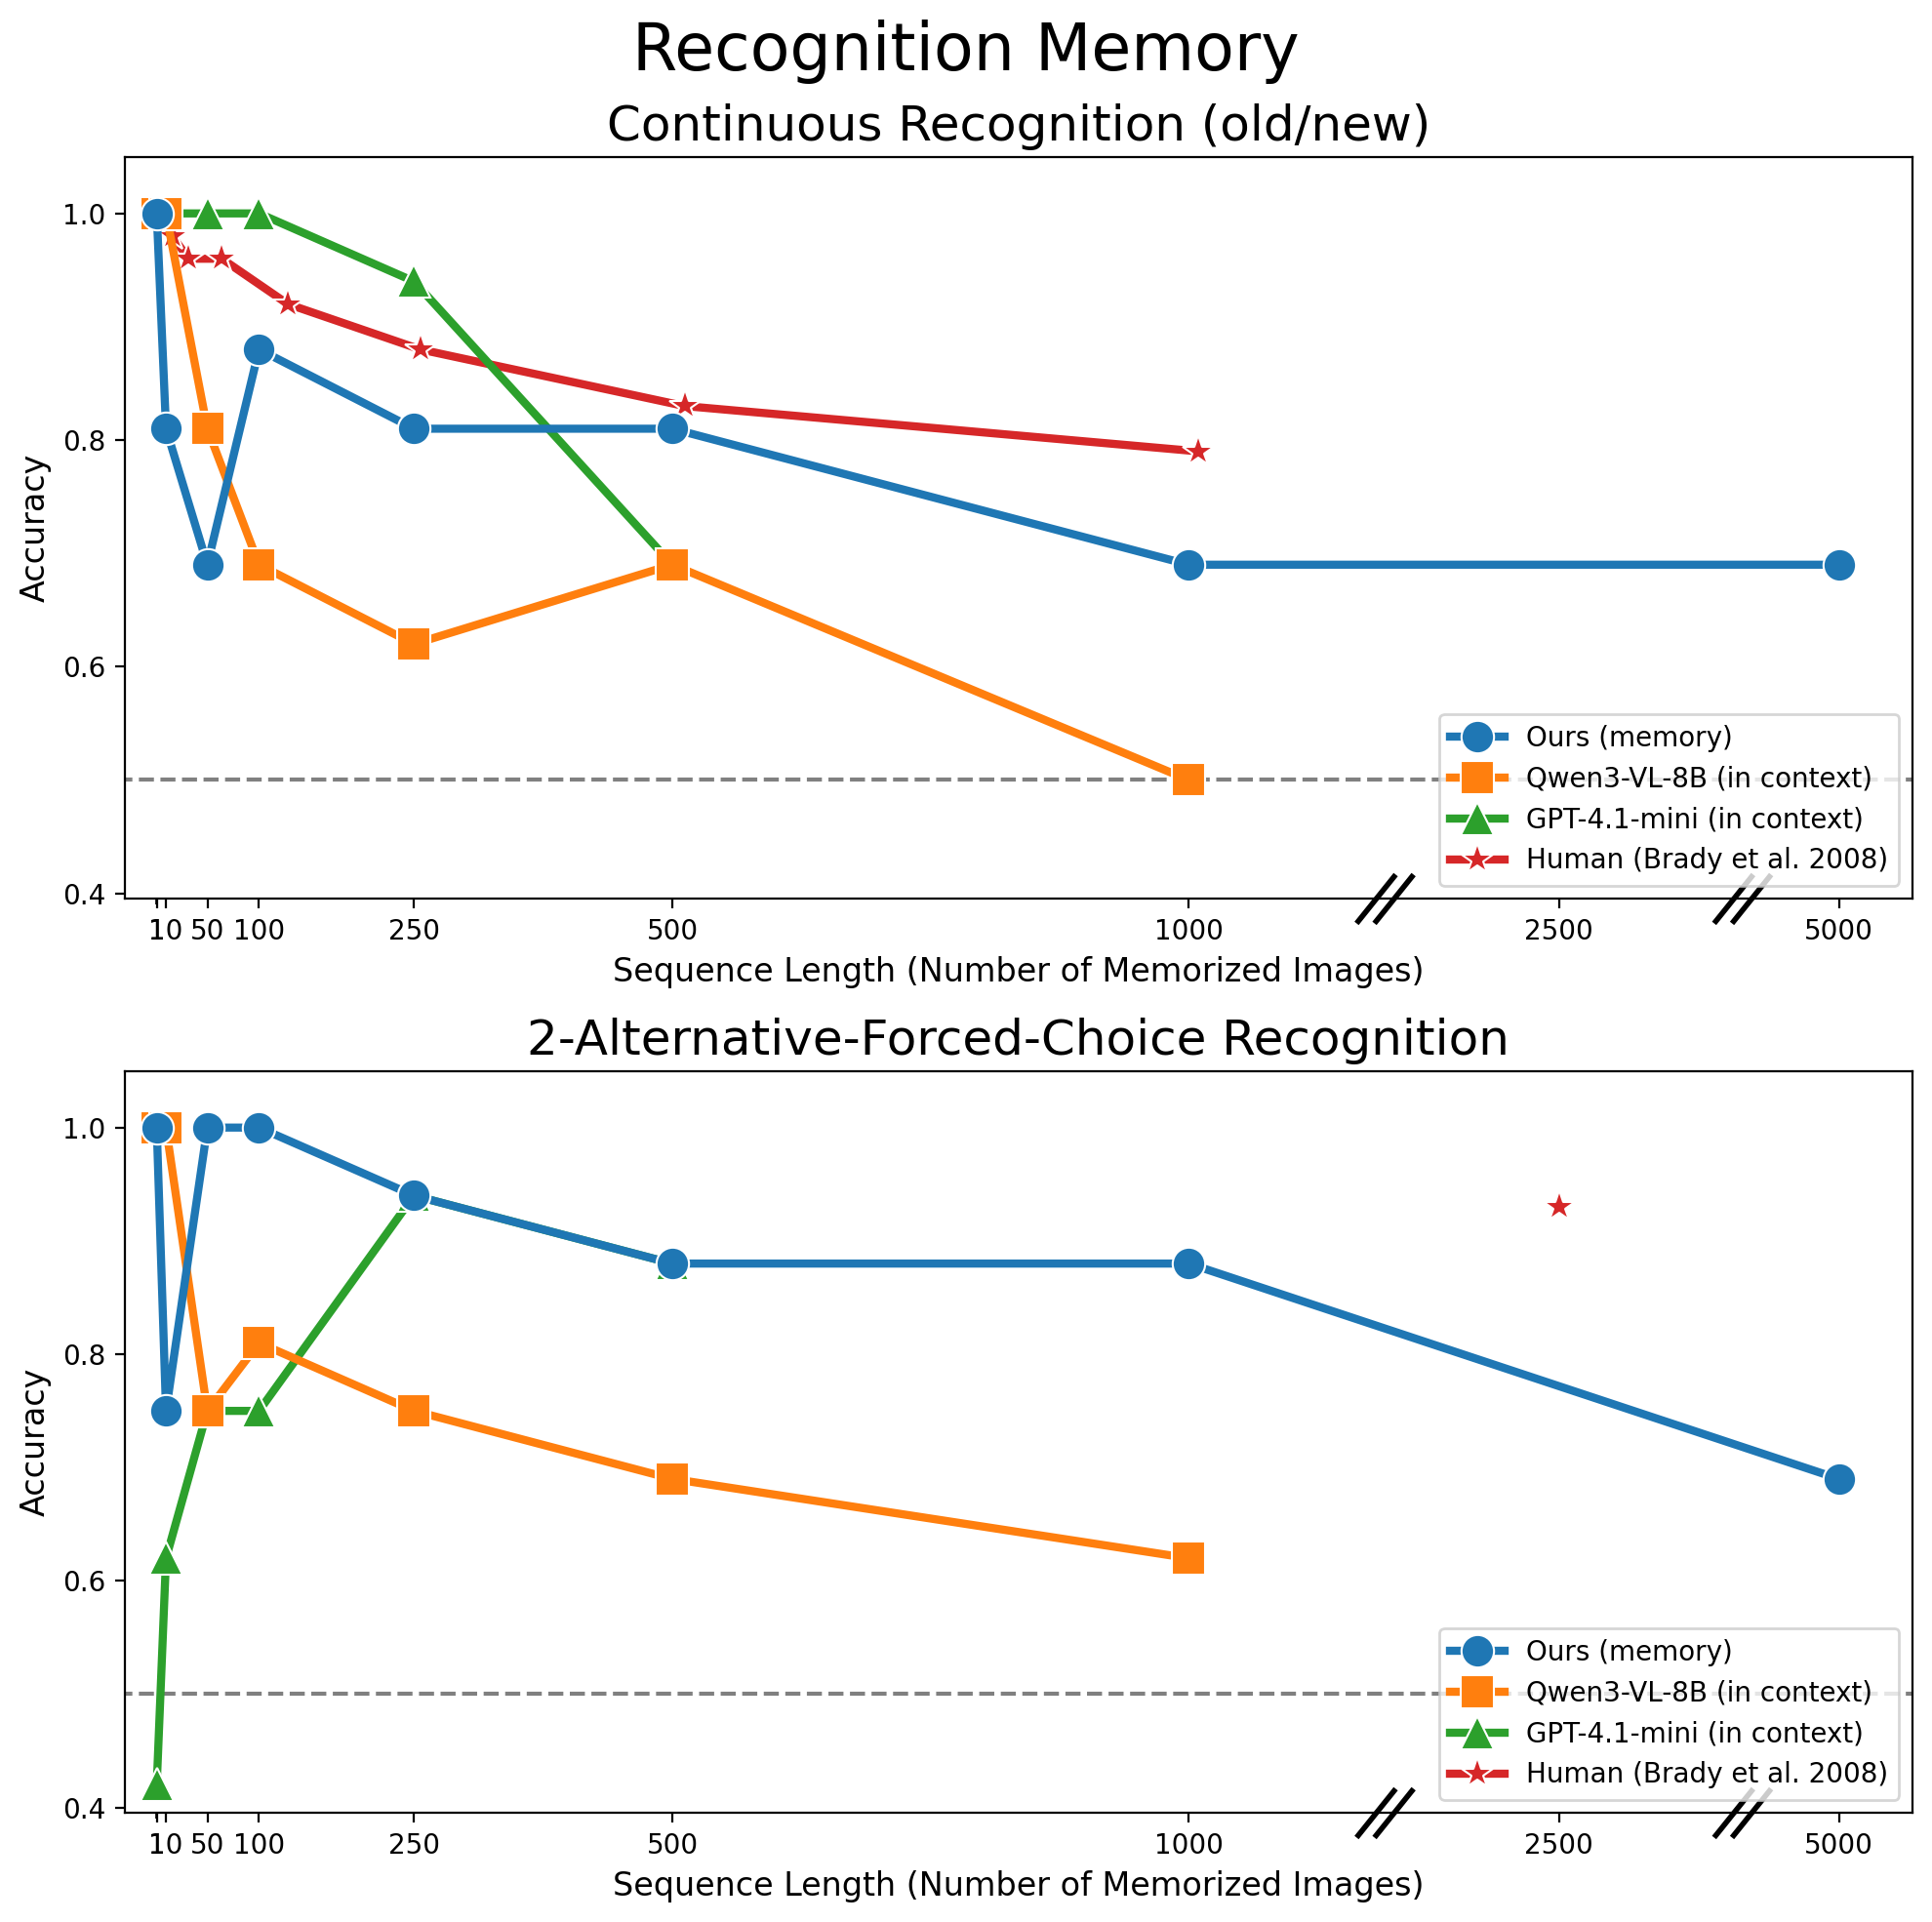

In [196]:
# 1. Define the hierarchy
# Legend: Ours (top), Qwen3, GPT, Human (bottom)
legend_order = [
    'Ours (memory)', 
    'Qwen3-VL-8B (in context)', 
    'GPT-4.1-mini (in context)', 
    'Human (Brady et al. 2008)'
]

# Plotting order (reversed legend order so the top legend item is drawn last/on top)
plot_order = list(reversed(legend_order))

marker_map = {
    'Human (Brady et al. 2008)': '*',        # Stars
    'Ours (memory)': 'o',                    # Circles
    'Qwen3-VL-8B (in context)': 's',         # Squares
    'GPT-4.1-mini (in context)': '^'          # Triangles
}

color_map = {
    'Human (Brady et al. 2008)': 'tab:red',
    'Ours (memory)': 'tab:blue',
    'Qwen3-VL-8B (in context)': 'tab:orange',
    'GPT-4.1-mini (in context)': 'tab:green'
}

fig, ax = plt.subplots(2, 1, figsize=(10, 10), dpi=200)
fig.suptitle('Recognition Memory', fontsize=24)

for a in ax:
    a.set_xscale('symlog', linthresh=1000)
    
    ticks = [1, 10, 50, 100, 250, 500, 1000, 2500, 5000]
    a.set_xticks(ticks)
    a.set_xticklabels([str(t) for t in ticks])
    
    a.set_yticks([0.4, 0.6, 0.8, 1.0])
    a.set_ylim(0.395, 1.05)
    a.set_xlim(-30, 6000)
    
    a.set_xlabel('Sequence Length (Number of Memorized Images)', fontsize=12)
    a.set_ylabel('Accuracy', fontsize=12)
    a.hlines(0.5, xmin=-100, xmax=6000, colors='gray', linestyles='dashed', zorder=0)

    # Parallel break lines
    d = 0.01
    kwargs = dict(transform=a.transAxes, color='k', clip_on=False, linewidth=2)
    for x_pos in [0.7, 0.9]:
        a.plot([x_pos - d, x_pos + d], [-d*3, d*3], **kwargs)
        a.plot([x_pos, x_pos + 2*d], [-d*3, d*3], **kwargs)

tasks = [(continuous_recognition_data, ax[0], 'Continuous Recognition (old/new)'),
         (afc_data, ax[1], '2-Alternative-Forced-Choice Recognition')]

for data, a, title in tasks:
    a.set_title(title, fontsize=18)
    
    # Plotting in plot_order (Human -> Ours) so Ours is on top
    for model in plot_order:
        model_data = data[data['model-id'] == model]
        if not model_data.empty:
            sns.lineplot(
                data=model_data, x='length', y='accuracy', 
                marker=marker_map[model], ax=a, linewidth=3, markersize=12,
                label=model, color=color_map[model]
            )
    
    # Manually reorder the legend to match legend_order
    handles, labels = a.get_legend_handles_labels()
    handle_dict = dict(zip(labels, handles))
    
    ordered_handles = [handle_dict[l] for l in legend_order if l in handle_dict]
    ordered_labels = [l for l in legend_order if l in handle_dict]
    
    a.legend(ordered_handles, ordered_labels, title="", loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('max-plot-chris-version.png', dpi=200)
plt.show()

### Pranati's baseline plots redone

- human data where possible
    - tab:red with stars
    - recognition continuous: curve
    - recognition AFC: one point
    - nothing for color memory
    - all the others: point(s)
- no tab:blue
- gpt is tab:green
- qwen is tab:orange
- ideally other tab colors for claude, gemini, molmo

- add one legend with all the models are the top, right under suptitle
- log scale the x-axes
- 

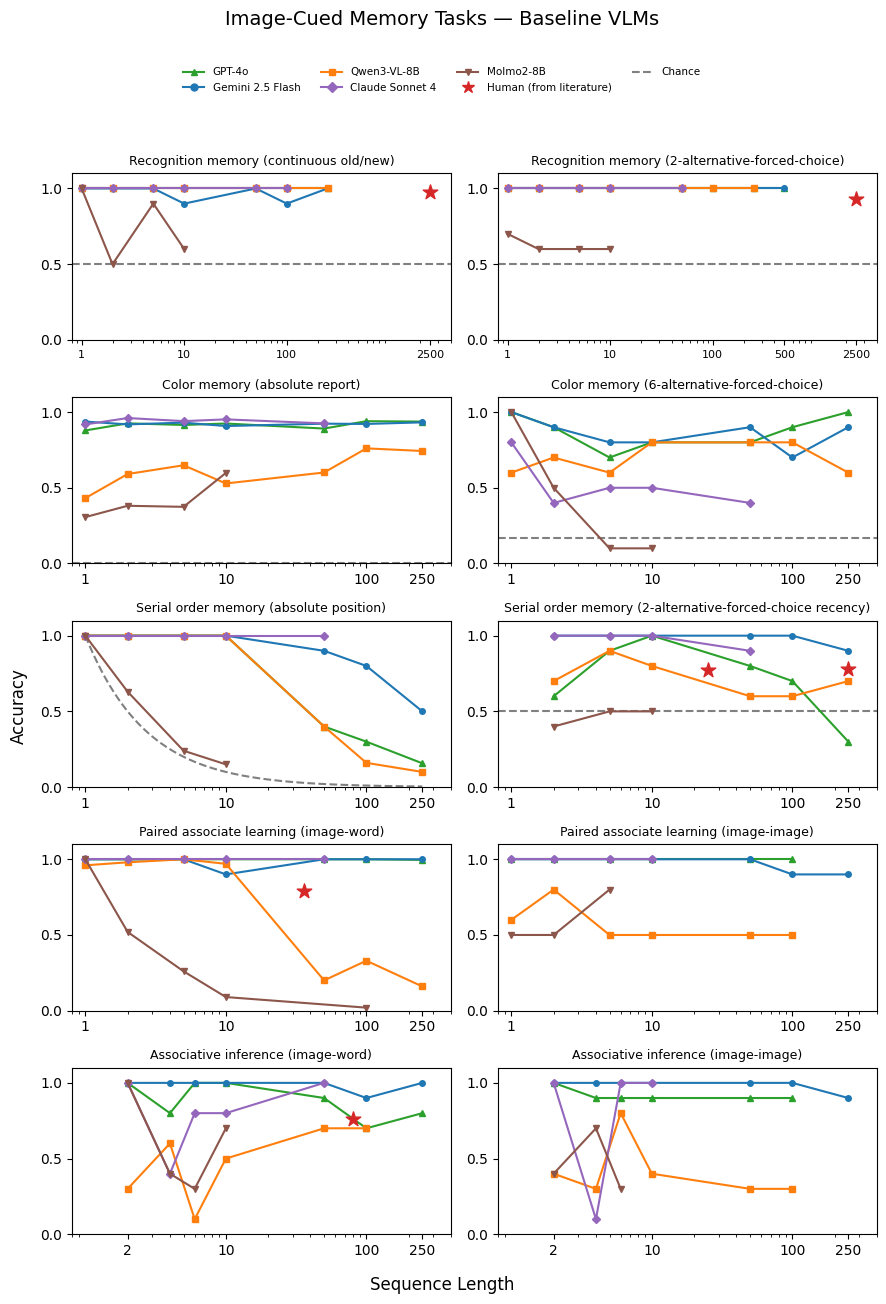

In [200]:
import json

# ── Load model data ──────────────────────────────────────────────────────────
with open('pranati-plot-chris-data.json') as f:
    data = json.load(f)

# ── Load literature data ─────────────────────────────────────────────────────
with open('../literature/recognition.json') as f:
    lit_recognition = json.load(f)
with open('../literature/serial_order.json') as f:
    lit_serial = json.load(f)
with open('../literature/paired_associates.json') as f:
    lit_pam = json.load(f)
with open('../literature/associative_inference.json') as f:
    lit_assoc = json.load(f)

# ── Styling ───────────────────────────────────────────────────────────────────
MODELS = ['gpt-4o', 'gemini-2.5-flash', 'qwen3-vl-8b', 'claude-sonnet-4-0', 'molmo2-8b']
MODEL_COLORS = {
    'gpt-4o':            'tab:green',
    'gemini-2.5-flash':  'tab:blue',
    'qwen3-vl-8b':       'tab:orange',
    'claude-sonnet-4-0': 'tab:purple',
    'molmo2-8b':         'tab:brown',
}
MODEL_MARKERS = {
    'gpt-4o':            '^',
    'gemini-2.5-flash':  'o',
    'qwen3-vl-8b':       's',
    'claude-sonnet-4-0': 'D',
    'molmo2-8b':         'v',
}
MODEL_LABELS = {
    'gpt-4o':            'GPT-4o',
    'gemini-2.5-flash':  'Gemini 2.5 Flash',
    'qwen3-vl-8b':       'Qwen3-VL-8B',
    'claude-sonnet-4-0': 'Claude Sonnet 4',
    'molmo2-8b':         'Molmo2-8B',
}
HUMAN_COLOR  = 'tab:red'
HUMAN_MARKER = '*'
HUMAN_MS     = 120   # scatter s=

def plot_models(ax, task_key):
    task_data = data.get(task_key, {})
    for model in MODELS:
        if model not in task_data:
            continue
        ns   = sorted(int(k) for k in task_data[model])
        accs = [task_data[model][str(n)] for n in ns]
        ax.plot(ns, accs, color=MODEL_COLORS[model], marker=MODEL_MARKERS[model],
                linewidth=1.5, markersize=4)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(5, 2, figsize=(9, 12))
plt.setp(ax, yticks=[0, 0.5, 1.0], ylim=(0, 1.1), xscale='log')

# default xticks for most panels
for a in ax.flat:
    a.set_xticks([1, 10, 100, 250])
    a.set_xticklabels(['1', '10', '100', '250'])
    a.set_xlim(0.8, 400)

# ── [0,0] Continuous recognition ─────────────────────────────────────────────
ax[0,0].set_title('Recognition memory (continuous old/new)', fontsize=9)
ax[0,0].hlines(0.5, xmin=0.8, xmax=4000, colors='gray', linestyles='dashed')
plot_models(ax[0,0], 'continuous_recognition')
# Human: Brady 2008 — balanced accuracy = (hit_rate + specificity) / 2 at n≈2500
brady_cont = lit_recognition['Brady2008Continuous']
human_cont_acc = (brady_cont['hit_rate_mean'] + (1 - brady_cont['false_alarm_rate'])) / 2
ax[0,0].scatter([2500], [human_cont_acc], color=HUMAN_COLOR, marker=HUMAN_MARKER,
                s=HUMAN_MS, zorder=5, label='Human (Brady 2008)')
ax[0,0].set_xlim(0.8, 4000)
ax[0,0].set_xticks([1, 10, 100, 2500])
ax[0,0].set_xticklabels(['1', '10', '100', '2500'], fontsize=8)

# ── [0,1] 2-AFC recognition (novel foils) ────────────────────────────────────
ax[0,1].set_title('Recognition memory (2-alternative-forced-choice)', fontsize=9)
ax[0,1].hlines(0.5, xmin=0.8, xmax=4000, colors='gray', linestyles='dashed')
plot_models(ax[0,1], '2afc_novel')
# Human: Brady 2008 — novel foil accuracy at n=2500
ax[0,1].scatter([2500], [lit_recognition['Brady2008AFC']['accuracy']['novel']],
                color=HUMAN_COLOR, marker=HUMAN_MARKER, s=HUMAN_MS, zorder=5,
                label='Human (Brady 2008)')
ax[0,1].set_xlim(0.8, 4000)
ax[0,1].set_xticks([1, 10, 100, 500, 2500])
ax[0,1].set_xticklabels(['1', '10', '100', '500', '2500'], fontsize=8)

# ── [1,0] Color memory — absolute hue ────────────────────────────────────────
ax[1,0].set_title('Color memory (absolute report)', fontsize=9)
ax[1,0].hlines(1/360, xmin=0.8, xmax=400, colors='gray', linestyles='dashed')
plot_models(ax[1,0], 'color_continuous')
# No directly comparable human literature accuracy for this task

# ── [1,1] Color memory — 6-AFC named ─────────────────────────────────────────
ax[1,1].set_title('Color memory (6-alternative-forced-choice)', fontsize=9)
ax[1,1].hlines(1/6, xmin=0.8, xmax=400, colors='gray', linestyles='dashed')
plot_models(ax[1,1], 'color_named')

# ── [2,0] Serial order — absolute position ────────────────────────────────────
ax[2,0].set_title('Serial order memory (absolute position)', fontsize=9)
x_chance = np.geomspace(1, 250, 500)
ax[2,0].plot(x_chance, 1 / x_chance, color='gray', linestyle='dashed')
plot_models(ax[2,0], 'serial_free')
# No human accuracy data (Sherman 2025 reports rank correlation, not accuracy)

# ── [2,1] Serial order — 2-AFC recency ───────────────────────────────────────
ax[2,1].set_title('Serial order memory (2-alternative-forced-choice recency)', fontsize=9)
ax[2,1].hlines(0.5, xmin=0.8, xmax=400, colors='gray', linestyles='dashed')
plot_models(ax[2,1], 'serial_afc')
# Human: Dubrow 2014 (n=25) and Sherman 2025 (n=250)
ax[2,1].scatter([25],  [lit_serial['2afc']['Dubrow2014']['accuracy']],
                color=HUMAN_COLOR, marker=HUMAN_MARKER, s=HUMAN_MS, zorder=5)
ax[2,1].scatter([250], [lit_serial['2afc']['Sherman 2025']['accuracy']],
                color=HUMAN_COLOR, marker=HUMAN_MARKER, s=HUMAN_MS, zorder=5)

# ── [3,0] PAM — image-word ───────────────────────────────────────────────────
ax[3,0].set_title('Paired associate learning (image-word)', fontsize=9)
plot_models(ax[3,0], 'pam_word')
# Human: Duncan 2014 (n=36)
ax[3,0].scatter([36], [lit_pam['Duncan2014']['accuracy']],
                color=HUMAN_COLOR, marker=HUMAN_MARKER, s=HUMAN_MS, zorder=5)

# ── [3,1] PAM — image-image ──────────────────────────────────────────────────
ax[3,1].set_title('Paired associate learning (image-image)', fontsize=9)
plot_models(ax[3,1], 'pam_image')
# No human literature data for image-image PAM

# ── [4,0] Associative inference — image-word ─────────────────────────────────
ax[4,0].set_title('Associative inference (image-word)', fontsize=9)
plot_models(ax[4,0], 'assoc_word')
# Human: Banino 2016 — AC (transitive) accuracy at n=80
ax[4,0].scatter([80], [lit_assoc['Banino2016']['AC_accuracy']],
                color=HUMAN_COLOR, marker=HUMAN_MARKER, s=HUMAN_MS, zorder=5)
ax[4,0].set_xticks([2, 10, 100, 250])
ax[4,0].set_xticklabels(['2', '10', '100', '250'])

# ── [4,1] Associative inference — image-image ─────────────────────────────────
ax[4,1].set_title('Associative inference (image-image)', fontsize=9)
plot_models(ax[4,1], 'assoc_image')
ax[4,1].set_xticks([2, 10, 100, 250])
ax[4,1].set_xticklabels(['2', '10', '100', '250'])

# ── Legend ────────────────────────────────────────────────────────────────────
model_handles = [
    plt.Line2D([0], [0], color=MODEL_COLORS[m], marker=MODEL_MARKERS[m],
               linewidth=1.5, markersize=5, label=MODEL_LABELS[m])
    for m in MODELS
]
human_handle  = plt.Line2D([0], [0], color=HUMAN_COLOR, marker=HUMAN_MARKER,
                            linestyle='None', markersize=9, label='Human (from literature)')
chance_handle = plt.Line2D([0], [0], color='gray', linestyle='dashed', label='Chance')

fig.legend(handles=model_handles + [human_handle, chance_handle],
           loc='upper center', ncol=4, fontsize=7.5,
           bbox_to_anchor=(0.5, 1.04), frameon=False)

plt.suptitle('Image-Cued Memory Tasks — Baseline VLMs', fontsize=14, y=1.08)
fig.supxlabel('Sequence Length', fontsize=12)
fig.supylabel('Accuracy', fontsize=12)

plt.tight_layout()
plt.savefig('pranati-plot-chris-version.png', dpi=200, bbox_inches='tight')
plt.show()